# Lab 6: Trajectory Planning (worked solutions)

Companion to `TrajectoryPlanningTemplate.ipynb` and `pdfs/Trajectory_Planning.pdf`.
Layout: **Task → Solution → How it works → Example / check**.

**The problem.** A point-to-point move from $q_0$ to $q_f$ can be done in many ways. A *path* is only the set of
configurations passed; a *trajectory* adds the timing: $q(t), \dot q(t), \ddot q(t)$. Sending the goal at once
(a step) asks for infinite acceleration. A **trapezoidal velocity profile** is the simplest smooth alternative:
speed up at the constant acceleration $a_{max}$, cruise at $v_{max}$, slow down at $-a_{max}$. If the move is too short to
reach $v_{max}$ the cruise disappears and the profile is a **triangle**.

$$
\text{trapezoidal } (|\Delta q| > v_{max}^2/a_{max}):\quad t_a = \tfrac{v_{max}}{a_{max}},\; t_c = \tfrac{|\Delta q| - v_{max}^2/a_{max}}{v_{max}},\; t_f = 2t_a+t_c
$$
$$
\text{triangular } (|\Delta q| \le v_{max}^2/a_{max}):\quad t_a = \sqrt{|\Delta q|/a_{max}},\; v_{peak} = a_{max}t_a,\; t_f = 2t_a
$$

The PDF's short questions (with answers) are at the end. The last tasks (18–19) can move the real robot: the
publishing cell was **not executed** here and stays off by default.

**Moodle quiz.** The gameplan lists a quiz before this lab; the short questions at the end are good practice for it.

## Setup

In [1]:
%matplotlib widget
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3
import labpaths          # solutions/labpaths.py: repo root on sys.path + URDF location

np.set_printoptions(precision=6, suppress=True)

---
## Task 1: Import the URDF

In [2]:
mycobot_urdf_path = labpaths.urdf_path()     # template: os.path.join(os.getcwd(), 'mycobot_280_gazebo.urdf')
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)

NOTE: mycobot_280_gazebo.urdf not found in the repo root.
      Using the fallback /home/mano-ub22/TUD/cobots/ros2_ws/src/mycobot_description/urdf/mycobot_280_pi/mycobot_280_pi.urdf
      (same kinematic chain as far as checked, see solutions/labpaths.py)
ERobot: firefighter, 6 joints (RRRRRR), geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ g_base         │       │ BASE   │ SE3()                                               │
│    1 │ joint1         │       │ g_base │ SE3()                                               │
│    2 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    3 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    

/tmp/ipykernel_62127/3513415727.py:2: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


**How it works:** same as in Labs 3–5. The model is only used to read the joint count and limits; trajectory planning
itself is pure maths on joint angles.

---
## Task 2: Joint-space dimension and limits

In [3]:
print('Number of joints:', mycobot.n)
print('Joint limits (if available):')
print(mycobot.qlim)
print('Joint ranges (deg):', np.degrees(mycobot.qlim[1] - mycobot.qlim[0]))

Number of joints: 6
Joint limits (if available):
[[-2.9321  -2.4434  -2.6179  -2.6179  -2.7052  -3.14159]
 [ 2.9321   2.4434   2.6179   2.6179   2.7925   3.14159]]
Joint ranges (deg): [335.99391  279.993015 299.989242 299.989242 314.995007 359.999696]


**How it works**
- `mycobot.n` = 6; `mycobot.qlim` is a 2×6 array (row 0 = lower, row 1 = upper limit, radians).
- The extra line prints the range of each joint in degrees (e.g. joint 1: 335°). These *position* limits are different
  from the velocity/acceleration limits used below; they only tell you which start and goal poses are allowed.
- Remember this: the largest range is about 360° = 6.28 rad. Task 9 will show why that matters.

---
## Scalar trapezoidal profile
## Task 3: The worked example from the PDF
$q_0 = 0°$, $q_f = 90°$, $v_{max} = 45°/\text{s}$, $a_{max} = 90°/\text{s}^2$. Expected: $t_a = 0.5$ s, $t_c = 1.5$ s, $t_f = 2.5$ s.

In [4]:
q0_deg = 0.0
qf_deg = 90.0
vmax_deg = 45.0
amax_deg = 90.0

dq_deg = qf_deg - q0_deg
dq_abs_deg = abs(dq_deg)

ta = vmax_deg / amax_deg                    # acceleration time
dq_accdec = vmax_deg**2 / amax_deg          # distance covered while accelerating and decelerating

is_trapezoidal = dq_abs_deg > dq_accdec     # can the move reach vmax?

if is_trapezoidal:
    tc = (dq_abs_deg - dq_accdec) / vmax_deg   # cruise duration
    tf = 2 * ta + tc                           # total time
else:
    tc = 0.0
    tf = 2 * np.sqrt(dq_abs_deg / amax_deg)
    vpeak = amax_deg * np.sqrt(dq_abs_deg / amax_deg)

print('dq (deg):', dq_deg)
print('ta (s):', ta)
print('dq_accdec (deg):', dq_accdec)
print('trapezoidal:', is_trapezoidal)
print('tc (s):', tc)
print('tf (s):', tf)

dq (deg): 90.0
ta (s): 0.5
dq_accdec (deg): 22.5
trapezoidal: True
tc (s): 1.5
tf (s): 2.5


**How it works, step by step**
- $t_a = v_{max}/a_{max}$: with constant acceleration the speed grows as $v = a t$, so reaching $v_{max}$ takes $v_{max}/a$.
  Here 45 / 90 = 0.5 s.
- Distance during a ramp: $\tfrac12 a t_a^2 = \tfrac12 v_{max}^2/a_{max}$. Acceleration **and** deceleration are two ramps,
  so together $v_{max}^2/a_{max}$ = 45² / 90 = **22.5°**.
- `is_trapezoidal = dq_abs_deg > dq_accdec` is a **boolean** (`True`/`False`). 90° > 22.5° ⇒ there is room to cruise.
- Cruise: the remaining $90 - 22.5 = 67.5°$ is covered at constant speed: $t_c = 67.5/45 = 1.5$ s.
- Total: $t_f = 2t_a + t_c = 1 + 1.5 = 2.5$ s.
- `abs(x)` is Python's absolute value; `np.sqrt` the square root (used only in the triangular branch).
- The `if/else` on a boolean picks one of two formulas: the code has two branches because the physics has two cases.

**Check by integrating the profile numerically (area under the velocity curve = distance):**

In [5]:
t_chk = np.linspace(0, tf, 100001)
v_chk = np.where(t_chk <= ta, amax_deg * t_chk,
        np.where(t_chk <= ta + tc, vmax_deg, vmax_deg - amax_deg * (t_chk - ta - tc)))
integrate = getattr(np, 'trapezoid', None) or np.trapz      # renamed in NumPy 2
print('area under the trapezoid (deg):', integrate(v_chk, t_chk))

area under the trapezoid (deg): 90.00000000000001


- `np.where(cond, a, b)` picks `a` where `cond` is true and `b` elsewhere, element-wise: two nested calls give three
  branches. `np.trapz(y, x)` (called `np.trapezoid` in newer NumPy) integrates numerically: the result is 90°, the move.

---
## Task 4: The same example in SI units

In [6]:
q0 = np.radians(q0_deg)        # start angle in rad
qf = np.radians(qf_deg)        # goal angle in rad
vmax = np.radians(vmax_deg)    # rad/s
amax = np.radians(amax_deg)    # rad/s^2

print('q0 (rad):', q0)
print('qf (rad):', qf)
print('vmax (rad/s):', vmax)
print('amax (rad/s^2):', amax)

ta_si = vmax / amax
tc_si = (abs(qf - q0) - vmax**2 / amax) / vmax
print('ta, tc, tf (s):', ta_si, tc_si, 2 * ta_si + tc_si)

q0 (rad): 0.0
qf (rad): 1.5707963267948966
vmax (rad/s): 0.7853981633974483
amax (rad/s^2): 1.5707963267948966
ta, tc, tf (s): 0.5 1.5 2.5


**How it works / why the times don't change**
- `np.radians(x)` multiplies by π/180. The times depend on **ratios**: $v_{max}/a_{max}$ has the unit "seconds" whether
  both are in °/s and °/s² or in rad/s and rad/s² (the conversion factor cancels). In $t_c$ the numerator has
  $|\Delta q|$ and $v^2/a$ (both angles) divided by $v$: the factor cancels there as well.
- Rule for the whole lab: **pick one unit system and stay in it**. The controller uses rad on its topics.

---
## Task 5: General timing logic

In [7]:
def scalar_profile_timing(q0, qf, vmax, amax):
    dq = qf - q0
    dq_abs = abs(dq)
    direction = np.sign(dq)                # +1, -1 (or 0 if there is no motion)

    ta_nom = vmax / amax                   # nominal acceleration time (if vmax is reached)
    dq_accdec = vmax**2 / amax             # distance needed to accelerate to vmax and stop again

    if dq_abs > dq_accdec:
        # trapezoidal
        ta = ta_nom
        tc = (dq_abs - dq_accdec) / vmax
        tf = 2 * ta + tc
        vpeak = vmax
        profile_type = 'trapezoidal'
    else:
        # triangular
        ta = np.sqrt(dq_abs / amax)        # accelerate the first half, decelerate the second
        tc = 0.0
        tf = 2 * ta
        vpeak = amax * ta                  # peak speed reached at the turning point
        profile_type = 'triangular'

    return {
        'dq': dq,
        'dq_abs': dq_abs,
        'direction': direction,
        'ta': ta,
        'tc': tc,
        'tf': tf,
        'vpeak': vpeak,
        'profile_type': profile_type,
    }

timing = scalar_profile_timing(q0, qf, vmax, amax)
timing

{'dq': 1.5707963267948966,
 'dq_abs': 1.5707963267948966,
 'direction': 1.0,
 'ta': 0.5,
 'tc': 1.5,
 'tf': 2.5,
 'vpeak': 0.7853981633974483,
 'profile_type': 'trapezoidal'}

**How it works**
- `np.sign(dq)` returns +1, −1 or 0: the direction of motion. All phase durations use $|\Delta q|$, and the direction
  is applied later when sampling (Task 6), exactly as the PDF says.
- **Triangular case, derivation:** no cruise, so accelerate for $t_a$, then decelerate for $t_a$. The distance is
  $2\cdot\tfrac12 a_{max}t_a^2 = a_{max}t_a^2 = |\Delta q|$, hence $t_a = \sqrt{|\Delta q|/a_{max}}$; the speed at the
  turning point is $v_{peak} = a_{max}t_a < v_{max}$.
- A function that **returns a dictionary** bundles all results under names, easier to use than six return values.
- For the PDF example the function reproduces the table: trapezoidal, $t_a = 0.5$, $t_c = 1.5$, $t_f = 2.5$.

**Example: the same function for several move lengths (vmax = 45°/s, amax = 90°/s²):**

In [8]:
print(f"{'|dq| [deg]':>10s} {'profile':>12s} {'ta':>6s} {'tc':>6s} {'tf':>6s} {'vpeak [deg/s]':>14s}")
for d_deg in (5, 10, 22.5, 30, 90, -90):
    r = scalar_profile_timing(0.0, np.radians(d_deg), np.radians(45), np.radians(90))
    print(f"{d_deg:10.1f} {r['profile_type']:>12s} {r['ta']:6.3f} {r['tc']:6.3f} {r['tf']:6.3f} {np.degrees(r['vpeak']):14.2f}")

|dq| [deg]      profile     ta     tc     tf  vpeak [deg/s]
       5.0   triangular  0.236  0.000  0.471          21.21
      10.0   triangular  0.333  0.000  0.667          30.00
      22.5   triangular  0.500  0.000  1.000          45.00
      30.0  trapezoidal  0.500  0.167  1.167          45.00
      90.0  trapezoidal  0.500  1.500  2.500          45.00
     -90.0  trapezoidal  0.500  1.500  2.500          45.00


- Below 22.5° the profile is triangular and the peak speed is below 45°/s. Exactly 22.5° is the borderline (peak = 45°/s,
  cruise time 0). The −90° move has the same timing as +90° (only the direction differs).

---
## Task 6: Sample position, velocity and acceleration
Formulas for each phase (with $dir$ the sign of the move):

| phase | $\ddot q$ | $\dot q$ | $q$ |
|---|---|---|---|
| acceleration, $0\le t\le t_a$ | $dir\,a_{max}$ | $dir\,a_{max}t$ | $q_0 + \tfrac12 dir\,a_{max}t^2$ |
| cruise, $t_a<t\le t_a+t_c$ | 0 | $dir\,v_{peak}$ | $q_0 + dir\,\big(\tfrac12 a_{max}t_a^2 + v_{peak}(t-t_a)\big)$ |
| deceleration, $t_a+t_c<t\le t_f$, $t_d = t-t_a-t_c$ | $-dir\,a_{max}$ | $dir\,(v_{peak} - a_{max}t_d)$ | $q_0 + dir\,\big(\tfrac12 a_{max}t_a^2 + v_{peak}t_c + v_{peak}t_d - \tfrac12 a_{max}t_d^2\big)$ |

In [9]:
def sample_scalar_profile(q0, qf, vmax, amax, dt):
    timing = scalar_profile_timing(q0, qf, vmax, amax)

    ta = timing['ta']
    tc = timing['tc']
    tf = timing['tf']
    direction = timing['direction']
    vpeak = timing['vpeak']

    t = np.arange(0.0, tf + dt, dt)

    q = np.zeros_like(t)
    qd = np.zeros_like(t)
    qdd = np.zeros_like(t)

    for i, ti in enumerate(t):
        if ti > tf:
            # np.arange can produce a last sample slightly after tf: hold the goal (stopped)
            q[i] = qf
            qd[i] = 0.0
            qdd[i] = 0.0
        elif ti <= ta:
            # acceleration phase
            qdd[i] = direction * amax
            qd[i] = direction * amax * ti
            q[i] = q0 + 0.5 * direction * amax * ti**2
        elif ti <= ta + tc:
            # cruise phase
            qdd[i] = 0.0
            qd[i] = direction * vpeak
            q[i] = q0 + direction * (0.5 * amax * ta**2 + vpeak * (ti - ta))   # end of accel + cruise distance
        else:
            # deceleration phase
            td = ti - ta - tc                                                    # time within decel phase
            qdd[i] = -direction * amax
            qd[i] = direction * (vpeak - amax * td)
            q[i] = q0 + direction * (0.5 * amax * ta**2 + vpeak * tc + vpeak * td - 0.5 * amax * td**2)

    return t, q, qd, qdd, timing

t, q, qd, qdd, timing = sample_scalar_profile(q0, qf, vmax, amax, dt=0.01)
print(timing)
print('q(tf) - qf =', q[-1] - qf, '   qd(tf) =', qd[-1])

{'dq': 1.5707963267948966, 'dq_abs': 1.5707963267948966, 'direction': 1.0, 'ta': 0.5, 'tc': 1.5, 'tf': 2.5, 'vpeak': 0.7853981633974483, 'profile_type': 'trapezoidal'}
q(tf) - qf = 0.0    qd(tf) = 0.0


**How it works**
- `t = np.arange(0.0, tf + dt, dt)`: the time samples; `np.zeros_like(t)` makes three result arrays of the same length.
- `for i, ti in enumerate(t):` visits each time with its index; the `if / elif / else` chooses the phase.
- The cruise position adds the distance of the acceleration ramp, $\tfrac12 a_{max}t_a^2$, to the constant-speed distance
  $v_{peak}(t-t_a)$. The deceleration position adds the ramp and cruise distances to what the deceleration has covered so far
  ($v_{peak}t_d - \tfrac12 a_{max}t_d^2$: the mirror image of the acceleration ramp).
- **A trap in the template:** for most moves the last time sample of `np.arange(0, tf + dt, dt)` is **after** $t_f$ (floating-point
  step). The deceleration formula would then keep decelerating: the velocity would turn negative and the position overshoot
  the goal. The first `if ti > tf:` branch prevents that by holding the goal. Check: `q[-1] - qf` is 0 and `qd[-1]` is 0.
- The printed dictionary is the timing from Task 5; `q[-1]` reaching `qf` shows the phase formulas fit together.

**Check: the three phases join without jumps** (position and velocity continuous):

In [10]:
print('max position step between samples (rad):', np.max(np.abs(np.diff(q))), ' (expected about vmax*dt =', vmax * 0.01, ')')
print('max velocity step between samples (rad/s):', np.max(np.abs(np.diff(qd))), ' (expected about amax*dt =', amax * 0.01, ')')
print('q monotonic:', bool(np.all(np.diff(q) >= -1e-12)))

max position step between samples (rad): 0.00785398163397466  (expected about vmax*dt = 0.007853981633974483 )
max velocity step between samples (rad/s): 0.015707963267949432  (expected about amax*dt = 0.015707963267948967 )
q monotonic: True


- Neighbouring samples never differ by more than one time step's worth of motion: no jumps. `np.diff(a)` gives the
  differences `a[i+1] - a[i]`.

---
## Task 7: Plot

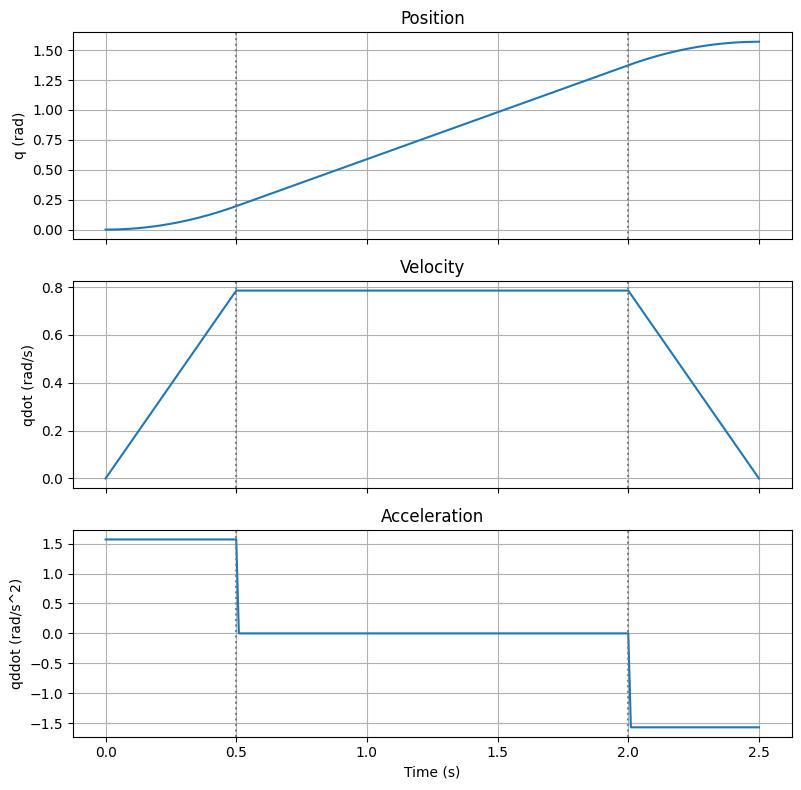

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t, q)
axes[0].set_ylabel('q (rad)')
axes[0].set_title('Position')
axes[0].grid(True)

axes[1].plot(t, qd)
axes[1].set_ylabel('qdot (rad/s)')
axes[1].set_title('Velocity')
axes[1].grid(True)

axes[2].plot(t, qdd)
axes[2].set_ylabel('qddot (rad/s^2)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Acceleration')
axes[2].grid(True)

ta_, tc_ = timing['ta'], timing['tc']
for ax in axes:                                    # mark the phase boundaries
    ax.axvline(ta_, color='gray', ls=':')
    ax.axvline(ta_ + tc_, color='gray', ls=':')

plt.tight_layout()

**How it works / reading the three plots** (this is also PDF question 4)
- `plt.subplots(3, 1, sharex=True)`: three plots stacked, sharing the time axis. `axvline(x)` draws a vertical line.
- **Acceleration:** three rectangles: $+a_{max}$, then 0, then $-a_{max}$. **Velocity:** ramp up, plateau at
  $v_{max}$, ramp down: the trapezoid. **Position:** parabola (accelerating), straight line (cruise), parabola
  (decelerating): an S-shaped curve with a flat start and end.
- Each plot is the **integral** of the one below it: the area under the acceleration is the velocity, the area under
  the velocity is the position. The dotted lines mark the phase boundaries at $t_a$ and $t_a + t_c$.
- Note the acceleration jumps instantly from $+a_{max}$ to 0 and to $-a_{max}$. That is why a trapezoidal profile is
  *not* jerk-limited (PDF question 3b).

---
## Joint-space trajectory for the myCobot 280
## Task 8: Start and goal

In [12]:
q_start = np.array([0.0, -np.pi/4, -np.pi/4, 0.0, np.pi/6, 0.0], dtype=float)
q_goal = np.array([np.pi/3, 0.0, -np.pi/2, np.pi/6, np.pi/3, -np.pi/4], dtype=float)

dq = q_goal - q_start
print('q_start:', q_start)
print('q_goal :', q_goal)
print('dq     :', dq)

# safe to plan? both inside the joint limits
inside = lambda q: bool(np.all((q >= mycobot.qlim[0]) & (q <= mycobot.qlim[1])))
print('start inside limits:', inside(q_start), ' goal inside limits:', inside(q_goal))

q_start: [ 0.       -0.785398 -0.785398  0.        0.523599  0.      ]
q_goal : [ 1.047198  0.       -1.570796  0.523599  1.047198 -0.785398]
dq     : [ 1.047198  0.785398 -0.785398  0.523599  0.523599 -0.785398]
start inside limits: True  goal inside limits: True


**How it works**
- Vector arithmetic: `q_goal - q_start` subtracts joint by joint. `dq` in degrees: [60, 45, −45, 30, 30, −45].
- `lambda q: ...` is a small anonymous function; here it checks whether all joints of `q` are inside the limits
  (`&` = element-wise "and").
- Both poses are inside the limits and no joint moves more than 60°: a moderate move.

---
## Task 9: Velocity and acceleration limits

In [13]:
# Codebase defaults from mycobot_control.py
vmax_all = np.radians(150.0)  # ~2.618 rad/s
amax_all = 1.0                # rad/s^2

print(f'vmax: {vmax_all:.4f} rad/s ({np.degrees(vmax_all):.1f} deg/s)')
print(f'amax: {amax_all:.4f} rad/s^2')
print(f'vmax^2/amax = {vmax_all**2 / amax_all:.3f} rad = {np.degrees(vmax_all**2 / amax_all):.0f} deg')

vmax: 2.6180 rad/s (150.0 deg/s)
amax: 1.0000 rad/s^2
vmax^2/amax = 6.854 rad = 393 deg


**How it works: an important observation**
- $v_{max}^2/a_{max} = 6.85$ rad $\approx 393°$. A joint only has to travel **more than that** to reach a cruise phase, but
  no myCobot joint can move more than 360°. So **with the controller's limits every point-to-point joint move is
  triangular**: the joint never gets to 150°/s. The **acceleration limit (1 rad/s²) is what limits the motion time**,
  not the velocity limit.
- Consequence for timing: a triangular move takes $t_f = 2\sqrt{|\Delta q|/a_{max}}$: quadrupling the distance only doubles the time.
- This is why the lab's worked example (Task 3) uses different numbers (45°/s and 90°/s²): with the robot's limits you
  would never see a trapezoid.

---
## Task 10: Minimum time per joint, and the slowest joint

In [14]:
joint_timings = []

for j in range(mycobot.n):
    tj = scalar_profile_timing(q_start[j], q_goal[j], vmax_all, amax_all)
    joint_timings.append(tj)

tf_joint = np.array([tj['tf'] for tj in joint_timings])
tf_sync = np.max(tf_joint)                    # the slowest joint sets the synchronized duration

print('Per-joint minimum times:', tf_joint)
print('Synchronized total time:', tf_sync)
print('Time-limiting joint index:', np.argmax(tf_joint), '(= joint', np.argmax(tf_joint) + 1, ')')
print('profile types:', [tj['profile_type'] for tj in joint_timings])

Per-joint minimum times: [2.046653 1.772454 1.772454 1.447203 1.447203 1.772454]
Synchronized total time: 2.046653415892977
Time-limiting joint index: 0 (= joint 1 )
profile types: ['triangular', 'triangular', 'triangular', 'triangular', 'triangular', 'triangular']


**How it works**
- One call of `scalar_profile_timing` per joint (list `joint_timings` of dictionaries), then a list comprehension
  `[tj['tf'] for tj in joint_timings]` extracts all `tf` values into an array.
- The joints must finish **together**, so the whole move takes as long as the slowest one: `np.max`; `np.argmax`
  gives its **index** (0-based: index 0 = joint 1).
- Result: joint 1 (60°, the largest move) needs 2.05 s; joint 4 and 5 (30°) would need only 1.45 s. All profiles are
  triangular (Task 9). If every joint used its own fastest profile, the arm would arrive at different times and the tool
  would move on a curved, unpredictable path. Synchronising makes all joints start and stop together.

---
## Task 11: How the controller synchronizes (`_build_ee_profile`)
Instead of building six profiles and stretching five of them, the controller:
1. finds the joint with the **largest displacement** (`max_delta`),
2. builds **one** trapezoidal/triangular profile for that joint,
3. scales all other joints proportionally: $q_j(t) = q_{start,j} + r_j\,(q_{dom}(t) - q_{start,dom})$ with
   $r_j = \Delta q_j/\Delta q_{dom}$.

All joints follow the same shape, so they start, peak and stop at the same instants. The controller also enforces a
minimum motion time `ee_min_time_s = 0.5` s so very short moves are not executed absurdly fast.

Why this is correct: scaling a profile by $r_j$ scales its position, velocity **and** acceleration by $r_j$. Since
$|r_j| \le 1$, no joint exceeds the limits that the dominant joint just satisfies.

---
## Task 12: Build the synchronized profiles

In [15]:
dt = 0.02

# Find the joint with the largest displacement (codebase: max_delta)
dq_abs = np.abs(dq)
dominant_joint = np.argmax(dq_abs)
max_delta = dq_abs[dominant_joint]

print(f'Dominant joint: {dominant_joint} (|dq| = {max_delta:.4f} rad)')

# Build the profile for the dominant joint
timing_dom = scalar_profile_timing(q_start[dominant_joint], q_goal[dominant_joint], vmax_all, amax_all)
tf_sync = timing_dom['tf']
print(f'Synchronized total time: {tf_sync:.4f} s ({timing_dom["profile_type"]})')

t_sync = np.arange(0.0, tf_sync + dt, dt)

q_traj = np.zeros((len(t_sync), mycobot.n))
qd_traj = np.zeros((len(t_sync), mycobot.n))
qdd_traj = np.zeros((len(t_sync), mycobot.n))

# Sample the dominant joint's profile
t_dom, q_dom, qd_dom, qdd_dom, _ = sample_scalar_profile(
    q_start[dominant_joint], q_goal[dominant_joint], vmax_all, amax_all, dt
)

# For each joint, scale its motion proportionally to the dominant joint
for j in range(mycobot.n):
    if max_delta < 1e-12:
        q_traj[:, j] = q_start[j]
        continue

    ratio = dq[j] / dq[dominant_joint]      # this joint's displacement relative to the dominant joint (signed)
    n_pts = min(len(t_sync), len(t_dom))

    for k in range(n_pts):
        q_traj[k, j] = q_start[j] + ratio * (q_dom[k] - q_start[dominant_joint])   # synchronized position
        qd_traj[k, j] = ratio * qd_dom[k]                                          # synchronized velocity
        qdd_traj[k, j] = ratio * qdd_dom[k]                                        # synchronized acceleration

    # Fill remaining points if t_sync is longer than t_dom
    if n_pts < len(t_sync):
        q_traj[n_pts:, j] = q_goal[j]

print('ratios:', dq / dq[dominant_joint])
print('samples:', len(t_sync))

Dominant joint: 0 (|dq| = 1.0472 rad)
Synchronized total time: 2.0467 s (triangular)
ratios: [ 1.    0.75 -0.75  0.5   0.5  -0.75]
samples: 104


**How it works**
- `np.argmax(dq_abs)`: index of the largest `|dq|`; `max_delta = dq_abs[dominant_joint]` its value.
- `ratio = dq[j] / dq[dominant_joint]`: **signed**, so joints that move the other way (negative ratio) work without extra
  code, and the dominant joint has ratio exactly 1.
- Position of joint *j*: its own start plus the ratio times the dominant joint's **progress** ($q_{dom}(t) - q_{start,dom}$).
  Velocity and acceleration: the ratio times the dominant joint's.
- `q_traj = np.zeros((len(t_sync), mycobot.n))`: a table with one row per time sample and one column per joint;
  `q_traj[k, j]` = joint *j* at sample *k*.
- `min(len(t_sync), len(t_dom))` protects against the two `arange` calls producing different lengths (same
  `dt` and `tf`, so equal here). The last `if` fills any remaining samples with the goal.
- **Vectorised equivalent** (no inner `k` loop): `q_traj[:n, j] = q_start[j] + ratio * (q_dom[:n] - q_start[dom])`.

In [16]:
n = min(len(t_sync), len(t_dom))
q_vec = np.zeros_like(q_traj)
for j in range(mycobot.n):
    q_vec[:n, j] = q_start[j] + (dq[j] / dq[dominant_joint]) * (q_dom[:n] - q_start[dominant_joint])
print('vectorised version identical:', np.allclose(q_vec[:n], q_traj[:n]))

vectorised version identical: True


---
## Task 13: Endpoints and continuity

In [17]:
print('q(0):', q_traj[0, :])
print('q(tf):', q_traj[-1, :])
print('qdot(0):', qd_traj[0, :])
print('qdot(tf):', qd_traj[-1, :])
print('start error (rad):', np.abs(q_traj[0] - q_start).max(), '   goal error (rad):', np.abs(q_traj[-1] - q_goal).max())

q(0): [ 0.       -0.785398 -0.785398  0.        0.523599  0.      ]
q(tf): [ 1.047198  0.       -1.570796  0.523599  1.047198 -0.785398]
qdot(0): [ 0.  0. -0.  0.  0. -0.]
qdot(tf): [ 0.  0. -0.  0.  0. -0.]
start error (rad): 0.0    goal error (rad): 0.0


**How it works / check**
- The first row equals `q_start`, the last row `q_goal` (errors ~1e-16); the start and end velocities are 0: the arm starts
  and stops smoothly (unlike a step command).
- Velocity 0 at the ends is automatic in this profile: the profile starts with $\dot q = a\cdot 0$ and ends with
  $\dot q = v_{peak} - a\,t_a = 0$.

---
## Task 14: Plot all six joints

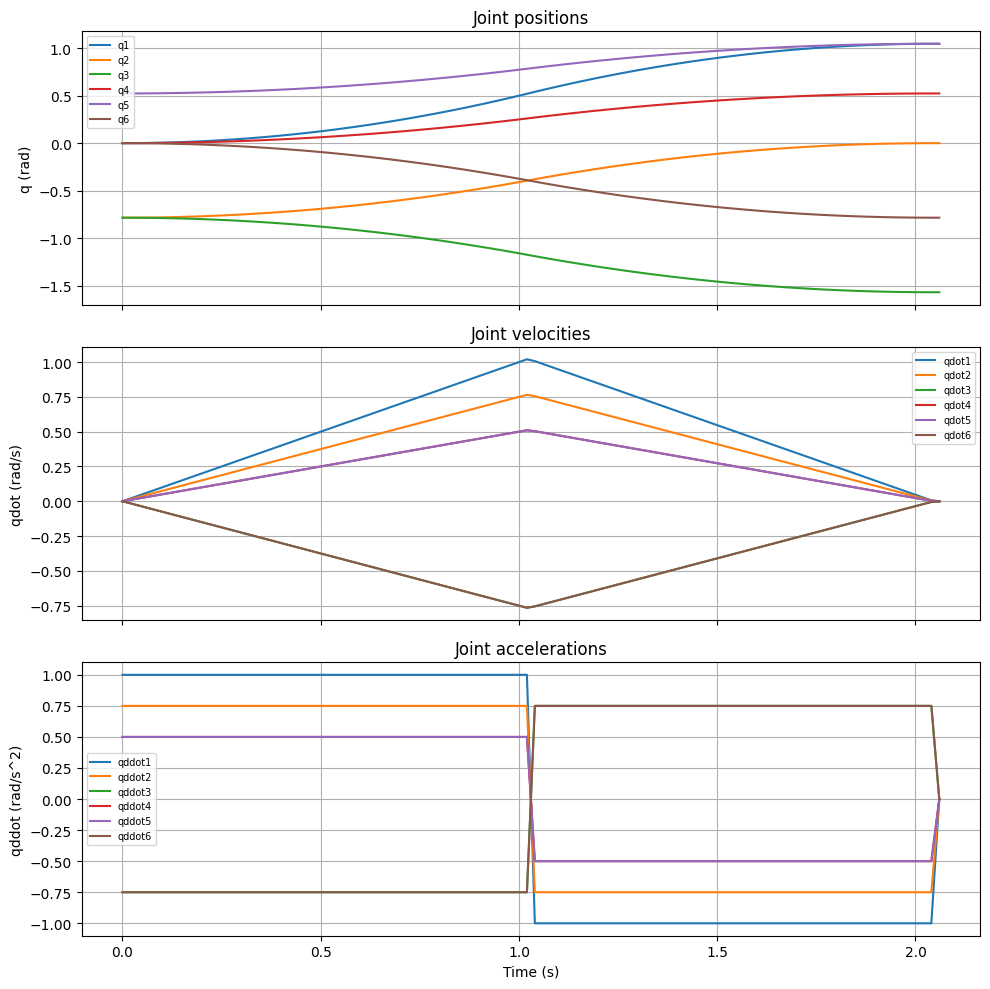

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for j in range(mycobot.n):
    axes[0].plot(t_sync, q_traj[:, j], label=f'q{j+1}')
    axes[1].plot(t_sync, qd_traj[:, j], label=f'qdot{j+1}')
    axes[2].plot(t_sync, qdd_traj[:, j], label=f'qddot{j+1}')

axes[0].set_ylabel('q (rad)')
axes[0].set_title('Joint positions')
axes[0].grid(True)
axes[0].legend(fontsize=7)

axes[1].set_ylabel('qdot (rad/s)')
axes[1].set_title('Joint velocities')
axes[1].grid(True)
axes[1].legend(fontsize=7)

axes[2].set_ylabel('qddot (rad/s^2)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Joint accelerations')
axes[2].grid(True)
axes[2].legend(fontsize=7)

plt.tight_layout()

**How it works / what you see**
- All six curves have the **same shape**, scaled by the ratios (largest for joint 1, negative for joints 3 and 6, which move
  the other way). They start, peak and stop at the same moments.
- The velocity curves are triangles (no cruise), peak speed of the dominant joint = 1.02 rad/s, far below 2.618 rad/s.
- The acceleration curves are two rectangles (+ then −): joint 1 has ±1.0 rad/s², the others less.

---
## Task 15: Constraint check

In [19]:
qd_peak = np.max(np.abs(qd_traj), axis=0)
qdd_peak = np.max(np.abs(qdd_traj), axis=0)

print('Peak |qdot|:', qd_peak)
print('Velocity limit:', vmax_all)
print('Velocity within limits:', bool(np.all(qd_peak <= vmax_all + 1e-9)))

print('Peak |qddot|:', qdd_peak)
print('Acceleration limit:', amax_all)
print('Acceleration within limits:', bool(np.all(qdd_peak <= amax_all + 1e-9)))

Peak |qdot|: [1.02  0.765 0.765 0.51  0.51  0.765]
Velocity limit: 2.6179938779914944
Velocity within limits: True
Peak |qddot|: [1.   0.75 0.75 0.5  0.5  0.75]
Acceleration limit: 1.0
Acceleration within limits: True


**How it works**
- `np.max(np.abs(a), axis=0)`: the largest absolute value in each **column**, i.e. one peak per joint.
- `np.all(cond)` is `True` only if every joint passes. The small `+ 1e-9` is a tolerance: a peak that equals the
  limit exactly (joint 1's acceleration is 1.0) could otherwise fail because of rounding.
- Both limits are met: the dominant joint reaches 1.0 rad/s² (the limit exactly, it is the joint that *sets* the
  limit) and the others less. Nothing else was needed: scaling with $|r_j| \le 1$ guarantees it.
- Wrapping `bool(...)` turns NumPy's `numpy.bool_` into a plain Python `True`/`False` for tidy printing.

---
## Triangular vs trapezoidal
## Task 16: A short move

In [20]:
# Short move: small displacement that cannot reach vmax
q0_short = 0.0
qf_short = 0.1          # rad (5.7 deg)
vmax_short = vmax_all
amax_short = amax_all

t_short, q_short, qd_short, qdd_short, timing_short = sample_scalar_profile(
    q0_short, qf_short, vmax_short, amax_short, dt=0.01
)

print(timing_short)
print('threshold vmax^2/amax =', vmax_all**2 / amax_all, ' > |dq| =', qf_short, '->', qf_short <= vmax_all**2 / amax_all)

{'dq': 0.1, 'dq_abs': 0.1, 'direction': 1.0, 'ta': 0.31622776601683794, 'tc': 0.0, 'tf': 0.6324555320336759, 'vpeak': 0.31622776601683794, 'profile_type': 'triangular'}
threshold vmax^2/amax = 6.853891945200944  > |dq| = 0.1 -> True


**How it works**
- |Δq| = 0.1 rad is far below the threshold 6.85 rad ⇒ **triangular**: `tc = 0`, `ta = sqrt(0.1) = 0.316 s`,
  `tf = 0.632 s`, peak speed 0.316 rad/s (only 12 % of $v_{max}$).
- **Comparison with the earlier example:** a trapezoid has a flat top and needs $|\Delta q| > v_{max}^2/a_{max}$; the short move
  has no flat top, and its time grows with the square root of the distance.

---
## Task 17: Plot the short move

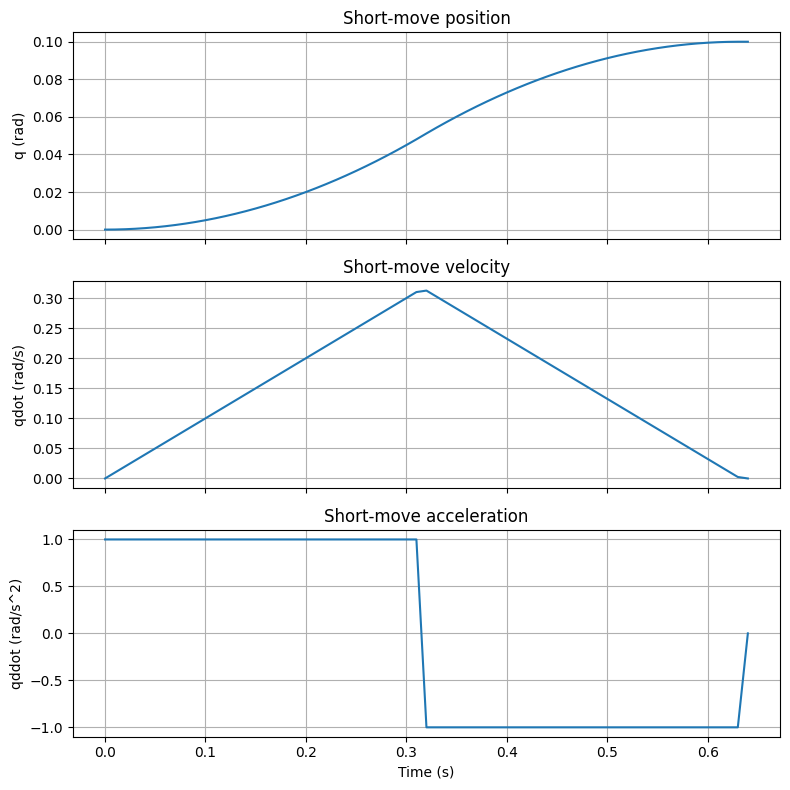

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t_short, q_short)
axes[0].set_ylabel('q (rad)')
axes[0].set_title('Short-move position')
axes[0].grid(True)

axes[1].plot(t_short, qd_short)
axes[1].set_ylabel('qdot (rad/s)')
axes[1].set_title('Short-move velocity')
axes[1].grid(True)

axes[2].plot(t_short, qdd_short)
axes[2].set_ylabel('qddot (rad/s^2)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Short-move acceleration')
axes[2].grid(True)

plt.tight_layout()

**Reading it:** the velocity rises linearly to the peak and falls linearly: a **triangle** with no flat segment. The
acceleration is +1 then −1 (two rectangles with no zero section between them).

**Example: the same robot, a *trapezoidal* profile** (lower speed limit, `vmax = 0.5 rad/s`, 1 rad move):

{'dq': 1.0, 'dq_abs': 1.0, 'direction': 1.0, 'ta': 0.5, 'tc': 1.5, 'tf': 2.5, 'vpeak': 0.5, 'profile_type': 'trapezoidal'}


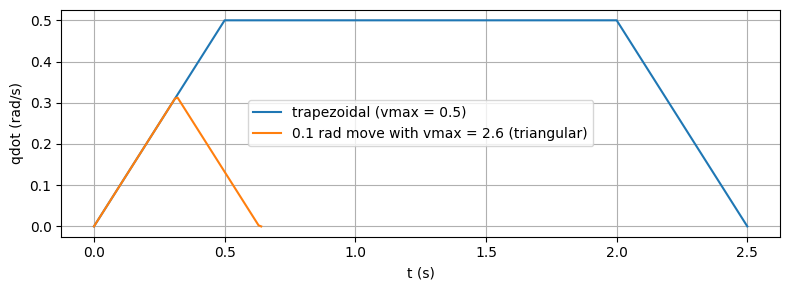

In [22]:
t_tr, q_tr, qd_tr, qdd_tr, timing_tr = sample_scalar_profile(0.0, 1.0, 0.5, 1.0, dt=0.01)
print(timing_tr)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_tr, qd_tr, label='trapezoidal (vmax = 0.5)')
ax.plot(t_short, qd_short, label='0.1 rad move with vmax = 2.6 (triangular)')
ax.set_xlabel('t (s)'); ax.set_ylabel('qdot (rad/s)'); ax.legend(); ax.grid(True)
plt.tight_layout()

- With $v_{max}=0.5$, $a_{max}=1$: $v_{max}^2/a_{max} = 0.25$ rad, the 1 rad move exceeds it, so the profile has a cruise
  phase: $t_a = 0.5$, $t_c = 1.5$, $t_f = 2.5$ s, the same numbers as the PDF example in SI form.

---
## Bridge to the practical workflow
## Task 18: Sample the trajectory for position commands

In [23]:
# Inspect the first few sampled joint targets
print('First 5 sampled joint commands (rad):')
print(q_traj[:5, :])

step = np.abs(np.diff(q_traj, axis=0))
print('largest change of any joint between two commands: %.4f rad = %.3f deg' % (step.max(), np.degrees(step.max())))
print('commands per second at dt = %.2f s: %.0f' % (dt, 1 / dt))

First 5 sampled joint commands (rad):
[[ 0.       -0.785398 -0.785398  0.        0.523599  0.      ]
 [ 0.0002   -0.785248 -0.785548  0.0001    0.523699 -0.00015 ]
 [ 0.0008   -0.784798 -0.785998  0.0004    0.523999 -0.0006  ]
 [ 0.0018   -0.784048 -0.786748  0.0009    0.524499 -0.00135 ]
 [ 0.0032   -0.782998 -0.787798  0.0016    0.525199 -0.0024  ]]
largest change of any joint between two commands: 0.0203 rad = 1.164 deg
commands per second at dt = 0.02 s: 50


**How it works**
- Each row of `q_traj` is one joint target at one time. Publishing the rows in order at the sample rate replays the
  trajectory as a sequence of position commands.
- The first steps are tiny (about 0.01° at the start) because the arm accelerates from rest; the largest step is about
  1.2° per 20 ms.
- **How the controller differs.** `/mycobot/joint_command` makes the controller send one `send_angles` command per message
  (speed 50); the `_build_ee_profile` used for end-effector targets instead generates velocity commands every tick (20 Hz).
  Streaming positions from a notebook is the simple alternative the template mentions.

---
## Task 19: Optional ROS 2 bridge to `/mycobot/joint_command`
**This can move the real arm. It was not executed here and is off by default (`publish_traj = False`).**

Problems with the template's cell, and what the version below does:
1. The trajectory starts at `q_start = [0, −45°, −45°, 0, 30°, 0]`. The real arm is somewhere else (e.g. the parked pose
   `[7.2, −99.3, −70.9, 81.4, 90.1, −74.3]`), so publishing the first row would make it **jump** to `q_start` at once:
   exactly the step that trajectory planning is meant to avoid. The version below plans **from the measured pose**.
2. Messages are published at the same `dt` as the sampling (50 Hz). The controller's tick is 20 Hz, so the cell resamples to 20 Hz.
3. Nothing checks the joint limits or the size of the move: `check_joint_target_rad` does, and the move is kept
   small (max 20° per joint).

In [ ]:
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import JointState
from std_msgs.msg import Float64MultiArray

if not rclpy.ok():
    rclpy.init(args=None)


class TrajectoryCommandNode(Node):
    def __init__(self):
        super().__init__('trajectory_planning_lab_node')
        self.pub = self.create_publisher(Float64MultiArray, '/mycobot/joint_command', 10)
        self.last_js = None
        self.sub = self.create_subscription(JointState, '/mycobot/joint_states', self._js_cb, 10)

    def _js_cb(self, msg):
        self.last_js = msg


traj_node = TrajectoryCommandNode()

In [ ]:
JOINT_LIMITS_DEG = np.array([[-168, 168], [-135, 135], [-150, 150], [-145, 145], [-165, 165], [-180, 180]])

def synchronized_profile(q_a, q_b, vmax, amax, dt):
    """Tasks 10-12 as a function: time, position, velocity, acceleration (n_samples x 6) from q_a to q_b."""
    d = q_b - q_a
    dom = int(np.argmax(np.abs(d)))
    if abs(d[dom]) < 1e-12:
        return np.array([0.0]), q_a[None, :], np.zeros((1, 6)), np.zeros((1, 6))
    t_d, q_d, qd_d, qdd_d, _ = sample_scalar_profile(q_a[dom], q_b[dom], vmax, amax, dt)
    r = d / d[dom]
    return t_d, q_a + np.outer(q_d - q_a[dom], r), np.outer(qd_d, r), np.outer(qdd_d, r)

def check_joint_target_rad(q_now, q_target, max_step_deg=15.0):
    q_now = np.asarray(q_now, dtype=float); q_target = np.asarray(q_target, dtype=float)
    lim = np.radians(JOINT_LIMITS_DEG)
    assert q_target.shape == (6,), "need exactly 6 joint values"
    assert np.all((q_target >= lim[:, 0]) & (q_target <= lim[:, 1])), f"outside joint limits: {np.degrees(q_target)}"
    step_deg = np.degrees(q_target - q_now)
    for j in range(6):
        print(f"J{j+1}: {np.degrees(q_now[j]):8.2f} -> {np.degrees(q_target[j]):8.2f} deg  ({step_deg[j]:+.2f})")
    assert np.all(np.abs(step_deg) <= max_step_deg), f"a joint moves more than {max_step_deg} deg"
    return q_target.tolist()


publish_traj = False   # a person sets this to True after reading the printed joint table and clearing the workspace

rclpy.spin_once(traj_node, timeout_sec=1.0)
assert traj_node.last_js is not None, "no joint state: is the controller running?"
q_measured = np.array(traj_node.last_js.position, dtype=float)

q_goal_safe = q_measured + np.radians([15, 10, -10, 0, 0, 0])          # a small move from where the robot really is
check_joint_target_rad(q_measured, q_goal_safe, max_step_deg=20)

pub_dt = 0.05                                                            # 20 Hz, the controller's tick rate
t_pub, q_pub, _, _ = synchronized_profile(q_measured, q_goal_safe, vmax_all, amax_all, pub_dt)
print(f'{len(t_pub)} commands, {t_pub[-1]:.2f} s')

if publish_traj:
    msg = Float64MultiArray()
    t0 = time.time()
    for k in range(len(t_pub)):
        msg.data = q_pub[k, :].tolist()            # joint targets in radians
        traj_node.pub.publish(msg)
        rclpy.spin_once(traj_node, timeout_sec=0.0)
        time.sleep(max(0.0, t0 + t_pub[k] + pub_dt - time.time()))   # keep the schedule, no drift
else:
    print('not published (publish_traj = False)')

# Optional cleanup:
# traj_node.destroy_node()
# rclpy.shutdown()

**How it works**
- `synchronized_profile` is Tasks 10–12 in one function; `np.outer(a, r)` makes the table `a[k] * r[j]` (rows = time,
  columns = joints) so `q_a + np.outer(...)` is exactly `q_start[j] + ratio_j * progress(t)`.
- `q_measured` = current pose from `/mycobot/joint_states`; the goal is a **small offset** from it. `check_joint_target_rad`
  prints the table and stops (`AssertionError`) if the goal is outside the limits or a joint would move too far.
- The loop schedules each message at `t0 + t_pub[k]`: `time.sleep(max(0, target_time - now))` waits exactly until then, so
  the timing does not drift when a cycle takes slightly longer (the template's fixed `time.sleep(dt)` adds the loop
  time to every step).
- `spin_once(node, 0.0)` lets our own state subscription keep receiving updates. The last message is the goal, so the
  arm ends exactly where planned.
- **Before enabling:** check the printed table, keep the workspace clear, and have the stop procedure ready (Lab 7).

---
## Short questions from the PDF (preparation for the quiz and interview)
1. **Objective of trajectory planning?** To turn a start and a goal (and constraints) into a **time-parameterised** reference
   $q(t), \dot q(t), \ddot q(t)$ that the robot can execute: smooth, within the velocity and acceleration limits, starting and ending at rest.
2. **Path vs trajectory?** A **path** is the geometric curve: the sequence of configurations/poses, without time. A
   **trajectory** is a path together with a timing law: where the robot is at each instant, and with which velocity and acceleration.
3. **True statements:** a) true (limits are the input of the planner); b) **false** for the trapezoidal profile: the acceleration
   jumps between $+a_{max}$, 0 and $-a_{max}$ (only smoother profiles such as S-curves or polynomials of higher order make it
   continuous); c) **false**: this planning is *kinematic*, it needs no dynamic model, just limits; d) true (position and
   velocity must be continuous, otherwise infinite velocity/acceleration would be required).
4. **Sketch:** velocity = trapezoid (ramp, plateau, ramp). Position = S-curve: parabola, straight line, parabola.
   Acceleration = three steps: $+a_{max}$, 0, $-a_{max}$. See the plot of Task 7.
5. **When is the profile triangular?** If $|\Delta q| \le v_{max}^2/a_{max}$: the joint would need to be already
   decelerating before it ever reached $v_{max}$.
6. **Three phases:** acceleration (velocity rises linearly to $v_{max}$, position quadratic); cruise (constant velocity,
   position linear); deceleration (velocity falls linearly to 0, position quadratic, mirror of the first).
7. **Influence of $v_{max}$ and $a_{max}$ on time:** trapezoid: $t_f = v_{max}/a_{max} + |\Delta q|/v_{max}$: a higher $v_{max}$
   shortens the cruise, a higher $a_{max}$ shortens the ramps. Triangular: $t_f = 2\sqrt{|\Delta q|/a_{max}}$: depends only on
   $a_{max}$; $v_{max}$ has no effect. (For the myCobot limits the moves are triangular, Task 9.)
8. **Why smooth profiles rather than step changes?** A step in position or velocity needs infinite acceleration: the servos
   saturate, the mechanics are stressed and vibrate, the tracking error and overshoot grow, and it is unsafe (the robot
   can jump). Smooth profiles keep position/velocity continuous and stay within the limits, so the motion is
   predictable and gentle on the hardware.

---
## Summary
- Trapezoid if $|\Delta q| > v_{max}^2/a_{max}$ else triangle; $t_f = 2t_a + t_c$ resp. $2\sqrt{|\Delta q|/a_{max}}$.
- Multi-joint: one dominant joint (largest $|\Delta q|$), others scaled by $r_j = \Delta q_j/\Delta q_{dom}$: same timing,
  limits automatically satisfied.
- With the controller's limits (150°/s, 1 rad/s²) all joint moves are triangular: the **acceleration** limit decides the time.
- Guard `np.arange` overshoot, plan from the **measured** pose, keep first tests small, publish at 20 Hz on schedule.